# Short-horizon mean reversion, and the edge it would have needed

Over a year, winners keep winning. Over a few days the textbook says they hand
it back: a name that fell hard against its peers bounces, because part of the
move was somebody needing to trade rather than somebody knowing something.

On thirty large caps since 2018, that effect is not there. Every formation
window tested below produces an information coefficient indistinguishable from
zero, which matches what the literature has been reporting about large-cap
reversal for two decades: the effect lives in small caps and it has decayed.

So this recipe does the more useful thing. It measures the strategy's turnover
honestly and computes the edge it would have needed to clear a realistic cost.
That number -- the required gross return, not the observed one -- is what tells
you whether to keep looking, and it is the calculation most short-horizon
research skips.

## Terms used here

| term            | meaning |
| --------------- | --- |
| mean reversion  | betting that a short-term move reverses rather than continues |
| cross-sectional | measuring each name against the other names that day, not against its own past |
| dollar neutral  | the same amount long as short, so the market direction cancels |
| z-score         | how many standard deviations from the average a value is |
| no-trade band   | leaving a position alone while the signal change is too small to pay for |
| break-even cost | the trading cost at which a strategy's net return is zero |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import h5i_db
from h5i_db import col, quant, sql_expr
import cookbook_utils as cu

FORMATION = 5
ANNUALIZE = float(np.sqrt(252))

## 1. The signal

The five-day return of each name, demeaned across the universe that day, and
negated: the worst relative performer gets the largest positive score. The
demeaning is what makes it a relative bet rather than a market timing call,
and `cs_demean` does it in the engine.

In [2]:
daily = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01")
db = h5i_db.Database(cu.fresh_db("alpha_mean_reversion"), create=True)
prices = daily.sort_by([("ts", "ascending"), ("symbol", "ascending")])
db.create_table("prices", prices.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("prices", prices, note="30 large caps, 2018-2026")
db.snapshot("prices-v1", tables=["prices"], note="Everything here reads this cut")

pinned = db.table("prices", snapshot="prices-v1")
previous = sql_expr("lag(adj_close)").over(partition_by="symbol", order_by="ts")
formation = sql_expr(f"lag(adj_close, {FORMATION})").over(
    partition_by="symbol", order_by="ts"
)
scored = (
    pinned.with_columns(previous=previous, formation=formation)
    .with_columns(
        ret=col("adj_close") / col("previous") - 1,
        window_return=col("adj_close") / col("formation") - 1,
    )
    .filter(col("ret").is_not_null() & col("window_return").is_not_null())
    .with_columns(relative=col("window_return").cs_demean(partition_by="ts"))
    .with_columns(score=col("relative") * -1.0)
)
signal_frame = scored.select(
    ts=col("ts"), asset=col("symbol"), ret=col("ret"), factor=col("score")
)
panel_frame = signal_frame.sort(["ts", "asset"]).to_pandas()
print(f"{len(panel_frame):,} symbol-days")
panel_frame.head(3).round(4)

63,870 symbol-days


/tmp/ipykernel_64198/829386453.py:28: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  panel_frame.head(3).round(4)


,ts,asset,ret,factor
0,2018-01-09 20:00:00+00:00,AAPL,-0.0001,0.0109
1,2018-01-09 20:00:00+00:00,ABBV,0.0075,0.0044
2,2018-01-09 20:00:00+00:00,AMZN,0.0047,-0.0306


## 2. Is it there at all?

Score the raw factor with the same panel machinery recipe 06/02 uses, across
every plausible formation window at once. Asking one window and reporting it is
how a t-statistic of one becomes a strategy.

In [3]:
price_frame = pinned.select(ts=col("ts"), asset=col("symbol"), price=col("adj_close"))


def reversal_panel(window: int):
    lag = sql_expr(f"lag(adj_close, {window})").over(partition_by="symbol", order_by="ts")
    frame = (
        pinned.with_columns(previous=previous, formation=lag)
        .with_columns(
            ret=col("adj_close") / col("previous") - 1,
            window_return=col("adj_close") / col("formation") - 1,
        )
        .filter(col("ret").is_not_null() & col("window_return").is_not_null())
        .with_columns(relative=col("window_return").cs_demean(partition_by="ts"))
        .with_columns(score=col("relative") * -1.0)
        .select(ts=col("ts"), asset=col("symbol"), factor=col("score"))
    )
    return quant.build_panel(db, frame, price_frame, periods=(1,), quantiles=5)


scan = []
for window in (1, 2, 3, 5, 10, 21):
    scanned = reversal_panel(window)
    row = scanned.ic_decay().to_pandas().iloc[0]
    buckets = scanned.quantile_returns().to_pandas()
    scan.append(
        {
            "formation": window,
            "mean IC": float(row["mean_ic"]),
            "t-stat": float(row["t_stat"]),
            "q5 - q1 (bp)": float(
                (buckets.iloc[-1]["mean_1"] - buckets.iloc[0]["mean_1"]) * 10_000
            ),
        }
    )
pd.DataFrame(scan).round(4)

,formation,mean IC,t-stat,q5 - q1 (bp)
0,1,0.0031,0.4992,-1.5204
1,2,0.0051,0.7927,0.0093
2,3,0.0061,0.9537,0.2587
3,5,-0.0043,-0.6646,-2.5709
4,10,0.0015,0.2277,-1.4568
5,21,0.0014,0.2185,0.0351


Nothing here clears a t-statistic of one, and the top-minus-bottom spread
changes sign across neighbouring windows. This is what absence looks like: not
a clean zero, but a set of small numbers with no agreement between them.

The rest of the recipe therefore stops asking whether to trade it and starts
asking what would have had to be true.

In [4]:
panel = reversal_panel(FORMATION)
quantiles = panel.quantile_returns().to_pandas()
top = quantiles.iloc[-1]["mean_1"]
bottom = quantiles.iloc[0]["mean_1"]
print(f"top bucket, one day     {top:+.5f} ({top * 10_000:+.1f} bp)")
print(f"bottom bucket, one day  {bottom:+.5f} ({bottom * 10_000:+.1f} bp)")
print(f"spread                  {(top - bottom) * 10_000:+.1f} bp per day")

top bucket, one day     -0.00003 (-0.3 bp)
bottom bucket, one day  +0.00023 (+2.3 bp)
spread                  -2.6 bp per day


## 3. A dollar-neutral portfolio

Weights proportional to the score, demeaned again to force dollar neutrality,
and normalised so gross exposure is one. Positions are decided on the close
and held the next day.

In [5]:
scores = panel_frame.pivot(index="ts", columns="asset", values="factor")
returns = panel_frame.pivot(index="ts", columns="asset", values="ret")
centred = scores.sub(scores.mean(axis=1), axis=0)
weights = centred.div(centred.abs().sum(axis=1), axis=0).fillna(0.0)

held = weights.shift(1).fillna(0.0)
gross = (held * returns).sum(axis=1)
turnover = (weights - weights.shift(1).fillna(0.0)).abs().sum(axis=1)
print(f"gross exposure        {held.abs().sum(axis=1).mean():.2f}x")
print(f"net exposure          {held.sum(axis=1).mean():+.4f}x")
print(f"daily turnover        {turnover.mean():.2f} of book")
print(f"gross Sharpe          {gross.mean() / gross.std() * ANNUALIZE:.2f}")
print(f"gross annual return   {gross.mean() * 252:.2%}")

gross exposure        1.00x
net exposure          +0.0000x
daily turnover        0.62 of book
gross Sharpe          -0.25
gross annual return   -2.70%


Turnover near one means the book is replaced every day. That is the whole
problem in one number: at one hundred per cent daily turnover, ten basis
points of cost is roughly twenty-five per cent a year.

In [6]:
costs = pd.DataFrame(
    [
        {
            "cost (bp)": bps,
            "annual cost": turnover.mean() * 252 * bps / 10_000,
            "net annual return": (gross - turnover * bps / 10_000).mean() * 252,
            "net Sharpe": (gross - turnover * bps / 10_000).mean()
            / (gross - turnover * bps / 10_000).std()
            * ANNUALIZE,
        }
        for bps in (0.0, 1.0, 2.0, 5.0, 10.0)
    ]
)
costs.round(4)

,cost (bp),annual cost,net annual return,net Sharpe
0,0.0,0.0000,-0.0270,-0.2527
1,1.0,0.0156,-0.0426,-0.3991
2,2.0,0.0312,-0.0583,-0.5458
3,5.0,0.0781,-0.1051,-0.9873
4,10.0,0.1562,-0.1832,-1.7279


## 4. The number that decides it

For a strategy that turns over most of its book daily, the useful statistic is
not the Sharpe, it is the *required* gross return: turnover times cost. Below
that line the strategy loses money however good the story is, and the line does
not depend on the signal at all.

The cost to compare against is not a guess either. Recipe 04/11 fits one from
a run's own fills, and recipe 04/08 shows what a few basis points of assumed
spread does to a much slower strategy.

In [7]:
required = pd.DataFrame(
    [
        {
            "cost (bp)": bps,
            "required gross (bp/day)": turnover.mean() * bps,
            "required gross (%/yr)": turnover.mean() * bps / 10_000 * 252,
            "observed gross (bp/day)": gross.mean() * 10_000,
        }
        for bps in (1.0, 2.0, 5.0, 10.0)
    ]
)
required.round(3)

,cost (bp),required gross (bp/day),required gross (%/yr),observed gross (bp/day)
0,1.0,0.620,0.016,-1.072
1,2.0,1.240,0.031,-1.072
2,5.0,3.099,0.078,-1.072
3,10.0,6.198,0.156,-1.072


In [8]:
print(f"observed gross return      {gross.mean() * 10_000:+.2f} bp per day")
print(f"turnover per day           {turnover.mean():.2f}")
print(f"required at 5bp            {turnover.mean() * 5.0:.2f} bp per day")
print(f"shortfall                  {turnover.mean() * 5.0 - gross.mean() * 10_000:.2f} bp per day")
print("\nA signal has to clear that line before its Sharpe means anything.")

observed gross return      -1.07 bp per day
turnover per day           0.62
required at 5bp            3.10 bp per day
shortfall                  4.17 bp per day

A signal has to clear that line before its Sharpe means anything.


## 5. Buying the turnover down

The lever that moves the required-return line is turnover, and the standard way
to move it is a no-trade band: leave the position alone unless the target has
moved enough to pay for the trade. It costs tracking error against the ideal
portfolio and takes the cost hurdle down with it.

In [9]:
def banded(threshold: float) -> dict:
    current = np.zeros(weights.shape[1])
    rows = []
    for _ts, target in weights.iterrows():
        move = target.to_numpy() - current
        traded = np.where(np.abs(move) > threshold, target.to_numpy(), current)
        rows.append(traded)
        current = traded
    positions = pd.DataFrame(rows, index=weights.index, columns=weights.columns)
    turned = (positions - positions.shift(1).fillna(0.0)).abs().sum(axis=1)
    raw = (positions.shift(1).fillna(0.0) * returns).sum(axis=1)
    net = raw - turned * 5.0 / 10_000
    return {
        "band": threshold,
        "daily turnover": float(turned.mean()),
        "required at 5bp (bp/day)": float(turned.mean() * 5.0),
        "observed gross (bp/day)": float(raw.mean() * 10_000),
        "net Sharpe at 5bp": float(net.mean() / net.std() * ANNUALIZE),
    }


bands = pd.DataFrame([banded(threshold) for threshold in (0.0, 0.002, 0.005, 0.01, 0.02)])
bands.round(3)

,band,daily turnover,required at 5bp (bp/day),observed gross (bp/day),net Sharpe at 5bp
0,0.000,0.620,3.099,-1.072,-0.987
1,0.002,0.618,3.088,-1.069,-0.984
2,0.005,0.607,3.035,-1.108,-0.981
3,0.010,0.575,2.876,-1.221,-0.973
4,0.020,0.496,2.480,-1.623,-0.979


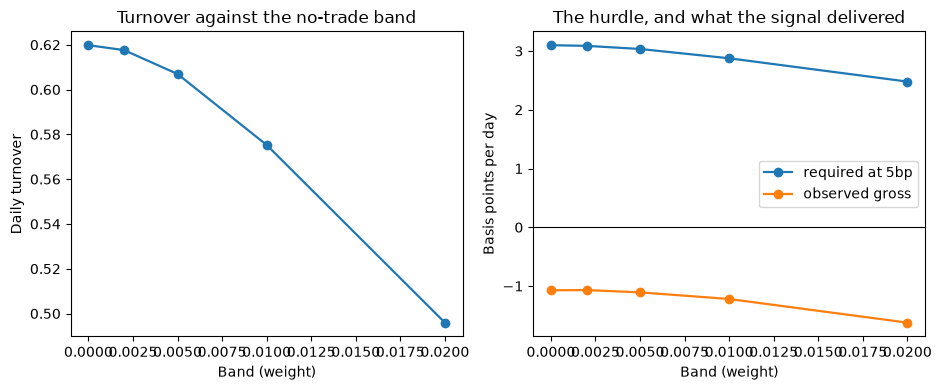

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
axes[0].plot(bands["band"], bands["daily turnover"], marker="o", linewidth=1.6)
axes[0].set_title("Turnover against the no-trade band")
axes[0].set_xlabel("Band (weight)")
axes[0].set_ylabel("Daily turnover")
axes[1].plot(bands["band"], bands["required at 5bp (bp/day)"], marker="o",
             linewidth=1.6, label="required at 5bp")
axes[1].plot(bands["band"], bands["observed gross (bp/day)"], marker="o",
             linewidth=1.6, label="observed gross")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("The hurdle, and what the signal delivered")
axes[1].set_xlabel("Band (weight)")
axes[1].set_ylabel("Basis points per day")
axes[1].legend()
fig.tight_layout()

Widening the band lowers the hurdle and moves the portfolio away from the one
the signal asked for. On a signal that worked, the operating point would be
where the gap between the two lines is largest. Here the two lines never cross,
which is the answer.

In [11]:
best = bands.loc[bands["net Sharpe at 5bp"].idxmax()]
print(f"best band              {best['band']:.3f}")
print(f"turnover there         {best['daily turnover']:.2f} per day "
      f"(from {bands.iloc[0]['daily turnover']:.2f})")
print(f"hurdle there           {best['required at 5bp (bp/day)']:.2f} bp/day "
      f"(from {bands.iloc[0]['required at 5bp (bp/day)']:.2f})")
print(f"observed gross there   {best['observed gross (bp/day)']:+.2f} bp/day")
print(f"still short by         "
      f"{best['required at 5bp (bp/day)'] - best['observed gross (bp/day)']:.2f} bp/day")

best band              0.010
turnover there         0.58 per day (from 0.62)
hurdle there           2.88 bp/day (from 3.10)
observed gross there   -1.22 bp/day
still short by         4.10 bp/day


## 6. What is still missing

Everything above is a daily-close simulation, so it assumes the whole book can
be traded at the close at one price. For a strategy that turns over most of
itself every day, that assumption is doing more work than the signal.

The path from here is recipe 04/08: turn these weights into target positions,
replay them against a book, and let the engine decide what filled. The
break-even number computed above is what makes that run worth the trouble --
it says in advance how much execution quality this strategy can afford.

In [12]:
print(f"a book of {len(returns.columns)} names turning over "
      f"{bands.iloc[0]['daily turnover']:.0%} a day trades "
      f"{bands.iloc[0]['daily turnover'] * 252:.0f}x its capital a year")
print(f"at the banded operating point that falls to "
      f"{best['daily turnover'] * 252:.0f}x")

a book of 30 names turning over 62% a day trades 156x its capital a year
at the banded operating point that falls to 145x


## Takeaways

- Scan every plausible formation window before believing one of them. Small
  numbers that disagree with each other are absence, not signal.
- Large-cap short-horizon reversal is not detectable in this universe, which is
  consistent with two decades of published work. Reporting that is the result.
- Demeaning cross-sectionally in the engine (`cs_demean`) is what makes the bet
  relative rather than directional.
- For a fast strategy the decisive number is the required gross return --
  turnover times cost -- and it does not depend on the signal at all.
- A no-trade band lowers the hurdle by lowering turnover, and costs fidelity to
  the portfolio the signal wanted.
- A daily-close backtest assumes the whole book trades at one price. For a
  strategy that replaces itself daily, that has to be tested against a book.

In [13]:
db.close()